In [16]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
from shapely.geometry import Point
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor

Load datasets and join based on coordinates.

In [ ]:
#compute nearest boundary distance in km
def getNearestBoundaryDist(point, boundaries):
    nearestBoundary = boundaries.geometry.distance(point).min() / 1000
    return nearestBoundary

#get the type of the nearest boundary
def getNearestBoundaryType(point, boundaries):
    distances = boundaries.geometry.distance(point)
    nearestIdx = distances.idxmin()
    return boundaries.loc[nearestIdx, 'Type']


earthquakeRaw = pd.read_csv('/Users/dingleberry/Visual studio code workspace/DSC400s/DSC478/Project/earthquakes.csv')
plates = gpd.read_file("/Users/dingleberry/Visual studio code workspace/DSC400s/DSC478/Project/PB2002_plates.json")
boundaries = gpd.read_file("/Users/dingleberry/Visual studio code workspace/DSC400s/DSC478/Project/PB2002_boundaries.json")

#print(earthquakeRaw.head())
# print(plates.crs)
# print(boundaries.crs)
# print(earthquakeRaw.shape)
#print(plates.columns)
#print(boundaries.columns)

#get plate areas
plates_54009 = plates.to_crs("ESRI:54009")
plates_54009["plate_area_km2"] = plates_54009.geometry.area / 1e6 #m2 to km2
#normalize
plates_54009["plate_area_norm"] = (plates_54009["plate_area_km2"] - plates_54009["plate_area_km2"].mean()) / plates_54009["plate_area_km2"].std()
plates = plates.merge(plates_54009[["PlateName", "plate_area_km2", "plate_area_norm"]], on="PlateName", how="left")

earthquakeRaw['regionCluster'] = KMeans(n_clusters=6, random_state=0).fit_predict(earthquakeRaw[['Latitude', 'Longitude']])

#convert to geo df
coordinates = [Point(xy) for xy in zip(earthquakeRaw['Longitude'], earthquakeRaw['Latitude'])]
earthquakeGeo = gpd.GeoDataFrame(earthquakeRaw, geometry=coordinates, crs="EPSG:4326")

#project to web mercator for distance calculations (meters)
earthquakeGeo = earthquakeGeo.to_crs(epsg=3857)
plates = plates.to_crs(epsg=3857)
boundaries = boundaries.to_crs(epsg=3857)

#spacial join to find which plate polygon each earthquake lies in
gdfEQxPlates= gpd.sjoin(earthquakeGeo, plates, how='left', predicate='within')

#fill boundary type NA values with unknown
boundaries['Type'] = boundaries['Type'].fillna('notSubduction')

############################
#engineer/transform features
############################

#get nearest boundary type
gdfEQxPlates['nearestBoundaryType'] = gdfEQxPlates.geometry.apply(lambda geom: getNearestBoundaryType(geom, boundaries))

#compute distance to nearest boundary
gdfEQxPlates['nearestBoundDist'] = gdfEQxPlates.geometry.apply(lambda geom: getNearestBoundaryDist(geom, boundaries))

#log scale focal depth
gdfEQxPlates['log_depth'] = np.log1p(gdfEQxPlates['Focal Depth (km)'])

#transform lat/lon to sin/cos
gdfEQxPlates['lat_sin'] = np.sin(np.radians(gdfEQxPlates['Latitude']))
gdfEQxPlates['lat_cos'] = np.cos(np.radians(gdfEQxPlates['Latitude']))
gdfEQxPlates['lon_sin'] = np.sin(np.radians(gdfEQxPlates['Longitude']))
gdfEQxPlates['lon_cos'] = np.cos(np.radians(gdfEQxPlates['Longitude']))

#transform month 
gdfEQxPlates['Mo_sin'] = np.sin(2 * np.pi * gdfEQxPlates['Mo'] / 12)
gdfEQxPlates['Mo_cos'] = np.cos(2 * np.pi * gdfEQxPlates['Mo'] / 12)

#tsu hot-one encode
gdfEQxPlates['Tsu'].fillna(False)
gdfEQxPlates['Tsu'] = gdfEQxPlates['Tsu']>0

#vol hot-one encode
gdfEQxPlates['Vol'].fillna(False)
gdfEQxPlates['Vol'] = gdfEQxPlates['Vol']>0


print(gdfEQxPlates.shape)
print(gdfEQxPlates.crs)
cols = gdfEQxPlates.columns
print(cols)

gdfEQxPlates = pd.get_dummies(gdfEQxPlates, columns=['nearestBoundaryType', 'PlateName', 'regionCluster'], prefix=['Boundary', 'Plate', 'region']) 

features = ['Year', 'Mo_sin', 'Mo_cos', 'lat_sin', 'lat_cos', 'lon_sin', 'lon_cos', 'plate_area_norm',
            'nearestBoundDist', 'log_depth', 'Tsu', 'Vol'] + [col for col in gdfEQxPlates.columns if 'Boundary' in col or 'region' in col]#or 'Plate' in col ]

print(features)


(2597, 53)
EPSG:3857
Index(['Year', 'Mo', 'Dy', 'Hr', 'Mn', 'Sec', 'Tsu', 'Vol', 'Location Name',
       'Latitude', 'Longitude', 'Focal Depth (km)', 'Mag', 'MMI Int', 'Deaths',
       'Death Description', 'Missing', 'Missing Description', 'Injuries',
       'Injuries Description', 'Damage ($Mil)', 'Damage Description',
       'Houses Destroyed', 'Houses Destroyed Description', 'Houses Damaged',
       'Houses Damaged Description', 'Total Deaths', 'Total Death Description',
       'Total Missing', 'Total Missing Description', 'Total Injuries',
       'Total Injuries Description', 'Total Damage ($Mil)',
       'Total Damage Description', 'Total Houses Destroyed',
       'Total Houses Destroyed Description', 'Total Houses Damaged',
       'Total Houses Damaged Description', 'regionCluster', 'geometry',
       'index_right', 'LAYER', 'Code', 'PlateName', 'plate_area_km2',
       'plate_area_norm', 'nearestBoundaryType', 'nearestBoundDist',
       'log_depth', 'lat_sin', 'lat_cos', 'lon_si

In [45]:
gdfEQxPlates[features].head

<bound method NDFrame.head of       Year  Mo   lat_sin   lat_cos   lon_sin   lon_cos  plate_area_norm  \
0     1961   1  0.766224  0.642574  0.405158 -0.914247        -0.306265   
1     1961   2  0.421036  0.907044  0.998301 -0.058261         0.204157   
2     1961   2  0.523986  0.851727  0.745476 -0.666532        -0.453588   
3     1961   3 -0.474088  0.880477 -0.074979 -0.997185         4.087724   
4     1961   3 -0.142629  0.989776  0.848048 -0.529919        -0.452036   
...    ...  ..       ...       ...       ...       ...              ...   
2558  2025   8 -0.867644  0.497186 -0.881477  0.472228         2.364204   
2559  2025   8  0.569366  0.822084  0.944336  0.328982         2.166118   
2560  2025   9  0.800658  0.599121  0.333593 -0.942717        -0.306265   
2561  2025   9  0.572590  0.819842  0.967784 -0.251782         2.166118   
2562  2025   9  0.193395  0.981121  0.827688 -0.561188         0.013038   

      nearestBoundDist  log_depth    Tsu    Vol  Boundary_  \
0      

Exploritory plots

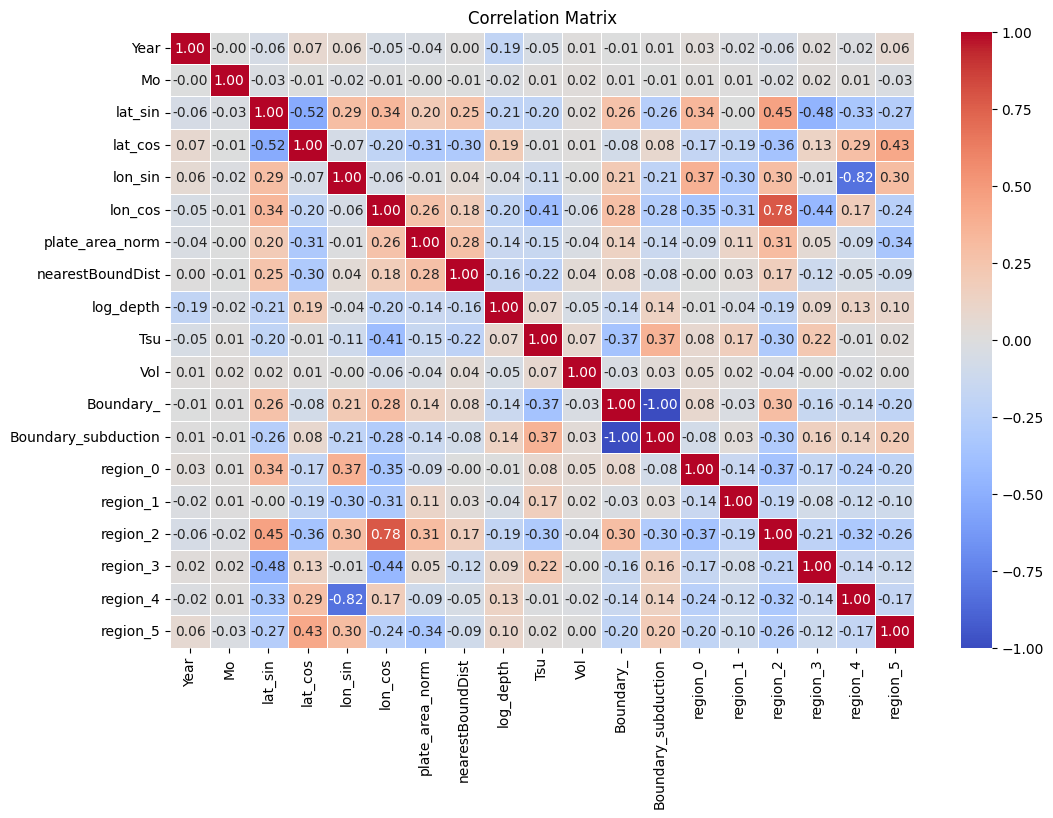

In [46]:
corrMat = gdfEQxPlates[features].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corrMat, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

Initial model Building and eval

RMSE for training data: 0.76180


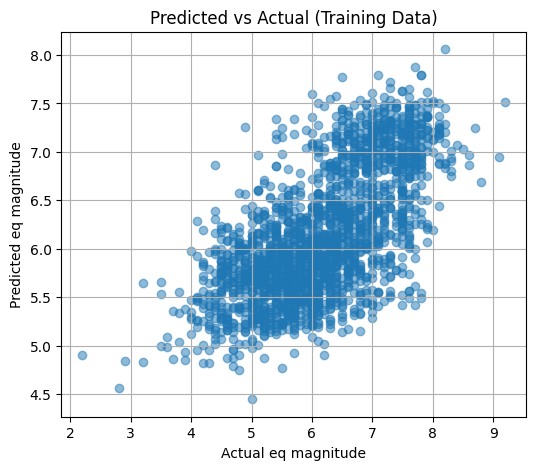

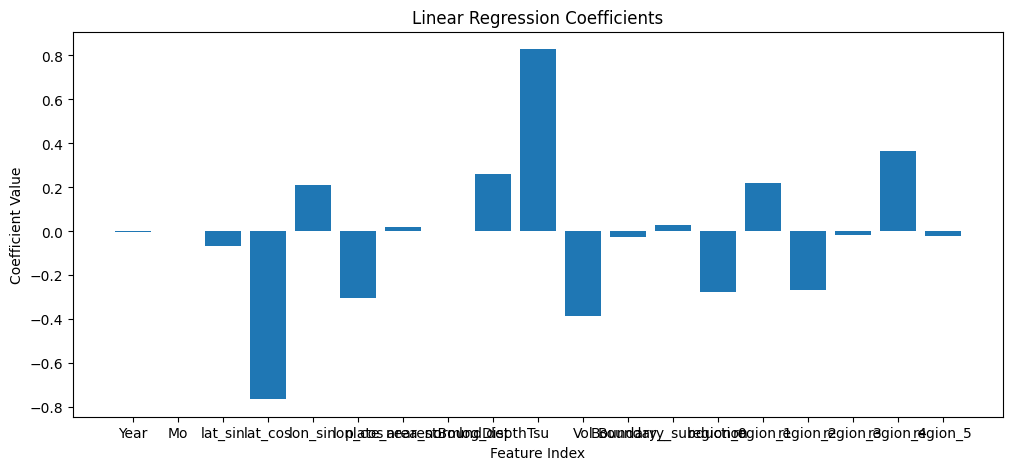


--- RMSE Comparison ---
Training RMSE: 0.7618
10-Fold Cross-Validation RMSE (mean): 0.7689


In [48]:
X = gdfEQxPlates[features]
y = gdfEQxPlates['Mag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rgr = LinearRegression()
rgr.fit(X_train, y_train)

trainPred = rgr.predict(X_train)

rmseTrain = np.sqrt(mean_squared_error(y_train, trainPred))
print(f"RMSE for training data: {rmseTrain:.5f}")

plt.figure(figsize=(6, 5))
plt.scatter(y_train, trainPred, alpha=0.5)
plt.xlabel("Actual eq magnitude")
plt.ylabel("Predicted eq magnitude")
plt.title("Predicted vs Actual (Training Data)")
plt.grid(True)
plt.show()

rgrCoef = pd.DataFrame({"Feature": X.columns, "Coefficient": rgr.coef_})

plt.figure(figsize=(12, 5))
plt.bar((rgrCoef["Feature"]), rgrCoef["Coefficient"])
plt.title("Linear Regression Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.show()

rgrCoef = rgrCoef.sort_values(by="Coefficient", ascending=False)

kfold = KFold(n_splits=10, shuffle=True, random_state=33)

rmse = -cross_val_score(rgr, X_train, y_train, scoring='neg_root_mean_squared_error', cv=kfold)

print("\n--- RMSE Comparison ---")
print(f"Training RMSE: {rmseTrain:.4f}")
print(f"10-Fold Cross-Validation RMSE (mean): {rmse.mean():.4f}")

feature importance

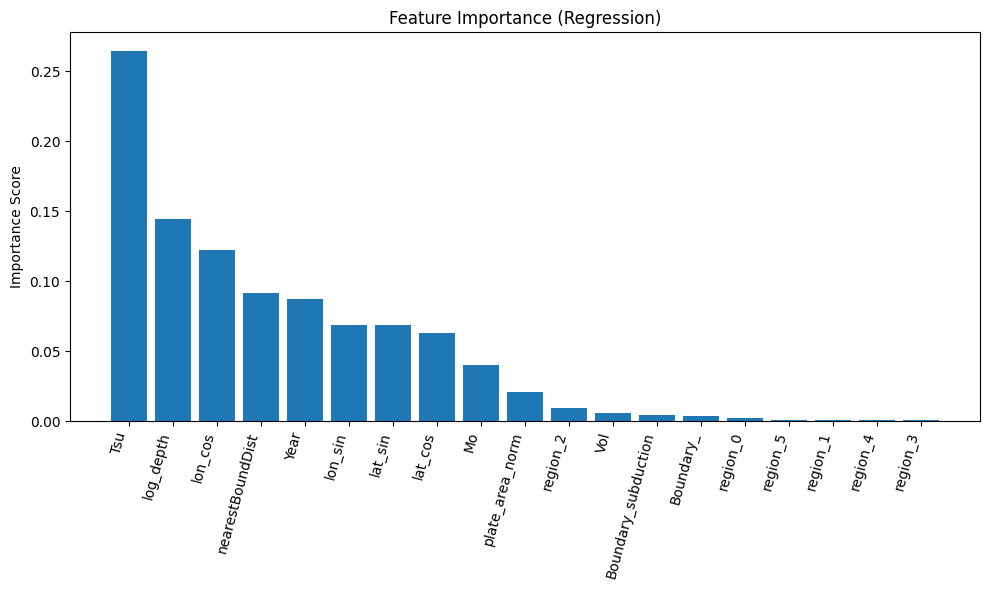

In [49]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
featureNames = X_train.columns

indices = np.argsort(importances)[::-1]
sortedFeatures = featureNames[indices]
sortedImportances = importances[indices]

plt.figure(figsize=(10, 6))
plt.bar(sortedFeatures, sortedImportances)
plt.xticks(rotation=75, ha='right')
plt.title("Feature Importance (Regression)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()